In [17]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [27]:
def num_antenna(SNR,Pt,Gt,Gr,sigma,wavelength,D,tau,Rt,Rr,B):
    wav=wavelength**2
    pi=(4*np.pi)**3
    Constant = k*Temp
    N = (SNR*pi*math.pow(Rt,2)*math.pow(Rr,2)*Constant*math.pow(B,0.5))/(Pt*Gt*Gr*sigma*wav*D*math.pow(tau,0.5))
    return N

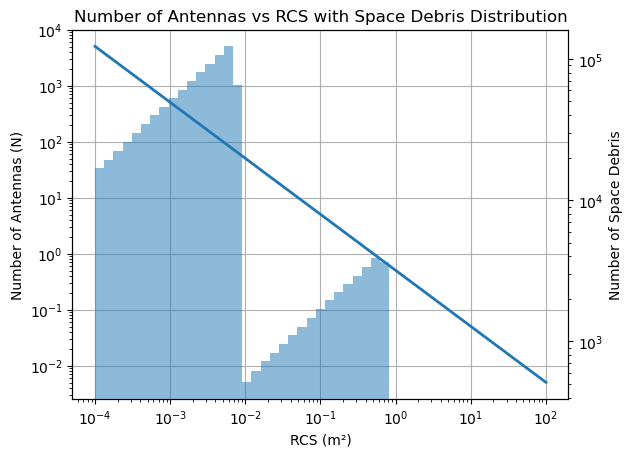

In [63]:
Pt = 235*1e3       #Transmitted Power of Aries
Gt = 2511.9         #Linear gain of Aries 34dbi
f = 206.5 *1e6     #Frequency of Aries
c=3*1e8
wavelength = c/f
Rt = 800e3   # 800 km
Rr = 800e3   # 800 km
D = 0.13     #Duty Cycle of Aries
k = 1.38*math.pow(10,-23)
Temp = 290
SNR = 10
tau = 0.5
B = 2*1e7
sigma_vals = np.logspace(-4, 2, 200)

N_vals = []
for s in sigma_vals:
    N_vals.append(num_antenna(SNR, Pt, Gt, Gr, s, wavelength, D, tau, Rt, Rr, B))

N_vals = np.array(N_vals)

size_bins = np.array([1e-3, 1e-2, 1e-1, 1])  
counts = np.array([1e8, 9e5, 3e4])

samples = []
for i in range(len(counts)):
    s = np.random.uniform(size_bins[i], size_bins[i+1], int(counts[i]/1))
    samples.extend(s)

samples = np.array(samples)

def size_to_rcs(d):
    return np.pi * (d/2)**2

rcs_debris = size_to_rcs(samples)

fig, ax1 = plt.subplots()

ax1.plot(sigma_vals, N_vals, linewidth=2)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel("RCS (m²)")
ax1.set_ylabel("Number of Antennas (N)")
ax1.grid()

ax2 = ax1.twinx()
ax2.hist(rcs_debris, bins=np.logspace(-4, 2, 50), alpha=0.5)
ax2.set_yscale('log')
ax2.set_ylabel("Number of Space Debris")

plt.title("Number of Antennas vs RCS with Space Debris Distribution")
plt.show()